# Task 1

In [1]:
# Task 1 - Vectorize It

import numpy as np
import time

prices = [
    20, 35, 45, 50, 60,
    25, 80, 100, 40, 55,
    75, 30, 90, 65, 120,
    15, 70, 85, 110, 95
]

tax_rate = 0.08

taxed_prices_loop = []

for price in prices:
    taxed_prices_loop.append(price * (1 + tax_rate))

print("Loop-based result:")
print(taxed_prices_loop)

price_array = np.array(prices)

taxed_prices_numpy = price_array * (1 + tax_rate)

print("\nNumPy result:")
print(taxed_prices_numpy)

print("\nResults are identical:")
print(np.allclose(taxed_prices_loop, taxed_prices_numpy))

threshold = 50

above_threshold = taxed_prices_numpy[taxed_prices_numpy > threshold]

print("\nTaxed prices above", threshold)
print(above_threshold)

numbers = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120]
])

row_sums = numbers.sum(axis=1)
column_sums = numbers.sum(axis=0)

print("\n2D Array:")
print(numbers)

print("\nRow sums:")
print(row_sums)

print("\nColumn sums:")
print(column_sums)


large_prices = np.random.randint(10, 1000, 1_000_000)

start = time.perf_counter()

loop_result = []

for price in large_prices:
    loop_result.append(price * 1.08)

loop_time = time.perf_counter() - start

start = time.perf_counter()

numpy_result = large_prices * 1.08

numpy_time = time.perf_counter() - start

print("\nPerformance comparison:")
print("Loop time:", loop_time)
print("NumPy time:", numpy_time)
print("Speedup:", loop_time / numpy_time)

Loop-based result:
[21.6, 37.800000000000004, 48.6, 54.0, 64.80000000000001, 27.0, 86.4, 108.0, 43.2, 59.400000000000006, 81.0, 32.400000000000006, 97.2, 70.2, 129.60000000000002, 16.200000000000003, 75.60000000000001, 91.80000000000001, 118.80000000000001, 102.60000000000001]

NumPy result:
[ 21.6  37.8  48.6  54.   64.8  27.   86.4 108.   43.2  59.4  81.   32.4
  97.2  70.2 129.6  16.2  75.6  91.8 118.8 102.6]

Results are identical:
True

Taxed prices above 50
[ 54.   64.8  86.4 108.   59.4  81.   97.2  70.2 129.6  75.6  91.8 118.8
 102.6]

2D Array:
[[ 10  20  30  40]
 [ 50  60  70  80]
 [ 90 100 110 120]]

Row sums:
[100 260 420]

Column sums:
[150 180 210 240]

Performance comparison:
Loop time: 2.704869499997585
NumPy time: 0.00243630000113626
Speedup: 1110.236628796153


# Task 2

In [2]:
# Task 2 - Load and Explore

import pandas as pd

df = pd.read_csv("employees.csv")

print("Employee Data:")
print(df)

print("\nDataFrame Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

department = "IT"

filtered_boolean = df[df["department"] == department]

print("\nIT employees using Boolean indexing:")
print(filtered_boolean)

filtered_query = df.query("department == 'IT'")

print("\nIT employees using query():")
print(filtered_query)

print("\nBoth filtering methods return the same rows:")
print(filtered_boolean.equals(filtered_query))

summary = df.groupby("department").agg(
    average_salary=("salary", "mean"),
    headcount=("name", "count")
)

summary = summary.sort_values(
    "average_salary",
    ascending=False
)

print("\nDepartment Summary:")
print(summary)

Employee Data:
      name department  salary  years_experience
0     Arun         IT   45000                 2
1    Priya         HR   38000                 3
2    Rahul    Finance   52000                 4
3    Sneha         IT   60000                 5
4    Vijay      Sales   42000                 2
5   Anjali         HR   41000                 4
6    Kiran    Finance   58000                 5
7    Meera         IT   55000                 3
8     Ravi      Sales   48000                 3
9    Divya    Finance   65000                 6
10  Suresh         IT   70000                 7
11   Pooja         HR   45000                 5
12  Naveen      Sales   50000                 4
13  Swathi         IT   62000                 6
14   Manoj    Finance   72000                 8

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 

# Task 3 

In [4]:
# Task 3 - Join the Data

import pandas as pd
import numpy as np

df = pd.read_csv("employees.csv")

departments = pd.DataFrame({
    "department": ["IT", "HR", "Finance", "Sales"],
    "department_budget": [500000, 300000, 600000, 400000]
})

print("Departments:")
print(departments)

inner_join = pd.merge(
    df,
    departments,
    on="department",
    how="inner"
)

print("\nInner Join:")
print(inner_join)

new_employee = pd.DataFrame({
    "name": ["Ramesh"],
    "department": ["Marketing"],
    "salary": [47000],
    "years_experience": [3]
})

df_with_unknown = pd.concat(
    [df, new_employee],
    ignore_index=True
)

left_join = pd.merge(
    df_with_unknown,
    departments,
    on="department",
    how="left"
)

print("\nLeft Join:")
print(left_join)

df_with_unknown.loc[2, "salary"] = np.nan
df_with_unknown.loc[5, "years_experience"] = np.nan

print("\nMissing values:")
print(df_with_unknown.isna().sum())

df_with_unknown["salary"] = df_with_unknown["salary"].fillna(
    df_with_unknown["salary"].mean()
)

df_with_unknown["years_experience"] = df_with_unknown["years_experience"].fillna(
    df_with_unknown["years_experience"].median()
)

print("\nData after handling missing values:")
print(df_with_unknown)

print("\nMissing values after handling:")
print(df_with_unknown.isna().sum())

Departments:
  department  department_budget
0         IT             500000
1         HR             300000
2    Finance             600000
3      Sales             400000

Inner Join:
      name department  salary  years_experience  department_budget
0     Arun         IT   45000                 2             500000
1    Priya         HR   38000                 3             300000
2    Rahul    Finance   52000                 4             600000
3    Sneha         IT   60000                 5             500000
4    Vijay      Sales   42000                 2             400000
5   Anjali         HR   41000                 4             300000
6    Kiran    Finance   58000                 5             600000
7    Meera         IT   55000                 3             500000
8     Ravi      Sales   48000                 3             400000
9    Divya    Finance   65000                 6             600000
10  Suresh         IT   70000                 7             500000
11   Pooja

# Task 4

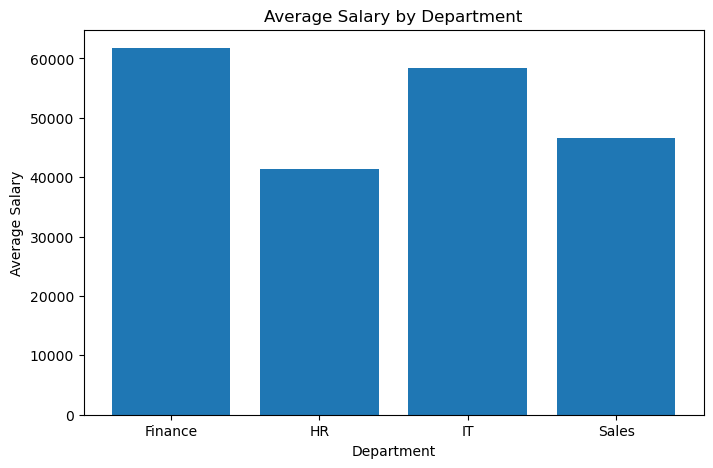

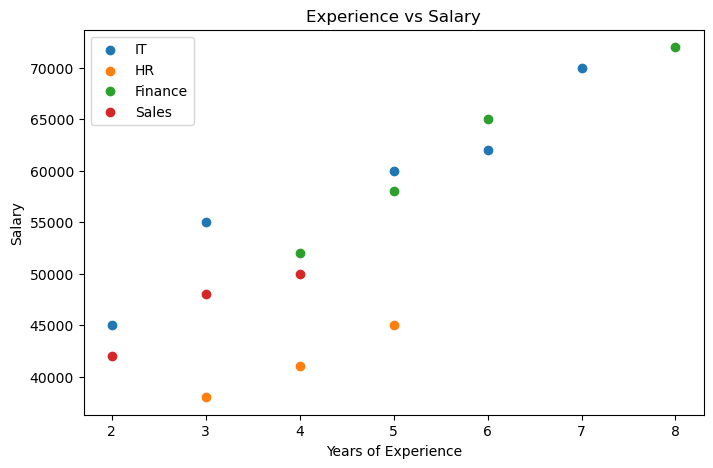

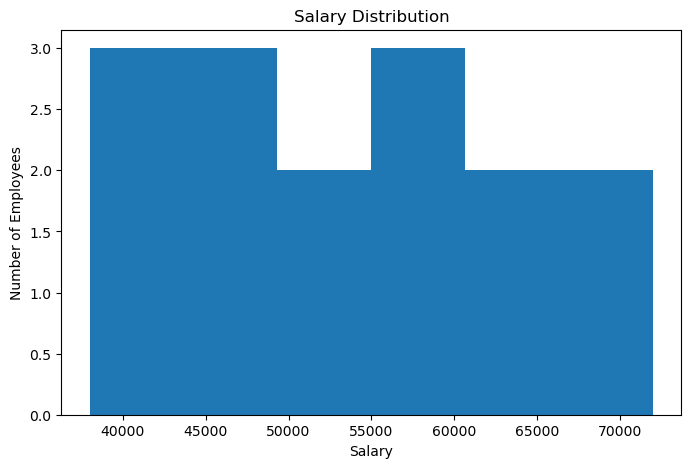

In [5]:
# Task 4 - Tell a Story

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("employees.csv")

department_salary = df.groupby("department")["salary"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    department_salary.index,
    department_salary.values
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()


plt.figure(figsize=(8, 5))

for department in df["department"].unique():
    department_data = df[df["department"] == department]

    plt.scatter(
        department_data["years_experience"],
        department_data["salary"],
        label=department
    )

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()

plt.show()


plt.figure(figsize=(8, 5))

plt.hist(
    df["salary"],
    bins=6
)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

# Task 5

In [8]:
# #1. Java habits I had to adjust
# OOP — Master Class 4

# One Java habit I had to adjust was thinking that classes and methods must always follow Java-style explicit type declarations and access modifiers. In Python, classes are more flexible, and concepts such as duck typing, dunder methods, and multiple inheritance work differently from Java.

# FastAPI/Testing — Master Class 5

# One Java habit I had to adjust was manually creating and validating request objects. With FastAPI and Pydantic, request data can be represented using a Pydantic model and validated automatically before reaching the endpoint logic.

# Pandas/NumPy — Master Class 6

# One habit I had to adjust was using loops for every operation. NumPy allows vectorized operations on entire arrays, while Pandas provides operations such as filtering, grouping, aggregation, and merging without manually iterating through every row.

# 2. Skill I expect to see again

# One skill I expect to use again is Pandas DataFrame filtering and aggregation. In upcoming ML modules, datasets will need to be cleaned, filtered, grouped, and analyzed before they are passed to machine-learning algorithms. NumPy will also appear when performing numerical operations on features and model data.

# 3. Least confident topic

# The topic I currently feel least confident about is Pandas merging and handling missing data. I will practice merge(), join types such as inner and left joins, isna(), dropna(), and fillna() using several small datasets until I can predict the output before running the code.

# Task 6

In [9]:
class Student:

    def __init__(self, name, marks):
        self.name = name
        self.marks = marks

    def __str__(self):
        return f"{self.name} scored {self.marks}"


student = Student("Rahul", 85)

print(student)

Rahul scored 85


In [11]:
pip install fastapi


  Attempting uninstall: typing-extensions

    Found existing installation: typing_extensions 4.12.2

    Uninstalling typing_extensions-4.12.2:

   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ---------------------------------------- 0/5 [typing-extensions]
   ----------------------------------

In [13]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()


class Student(BaseModel):
    name: str
    marks: float


@app.post("/students")
def create_student(student: Student):
    return {
        "name": student.name,
        "marks": student.marks
    }

In [14]:
import pandas as pd

df = pd.DataFrame({
    "department": ["IT", "IT", "HR", "HR", "Sales"],
    "salary": [50000, 60000, 40000, 45000, 55000],
    "name": ["A", "B", "C", "D", "E"]
})

result = df.groupby("department").agg(
    average_salary=("salary", "mean"),
    headcount=("name", "count")
)

print(result)

            average_salary  headcount
department                           
HR                 42500.0          2
IT                 55000.0          2
Sales              55000.0          1
